1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Everything works!")

Matplotlib is building the font cache; this may take a moment.


NumPy: 2.4.6
Pandas: 3.0.5
Everything works!


2. Load Dataset

In [ ]:
import pandas as pd
df = pd.read_excel(r'..\data\raw\Online Retail.xlsx')
print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 541,909
Columns: 8


3. Data Understanding

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
df.shape

(541909, 8)

In [6]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
df.describe(include='object')

C:\Users\Hp\AppData\Local\Temp\ipykernel_23132\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


4. Data Cleaning

In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
data_quality = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes.astype(str),
    'Missing_Values': df.isnull().sum().values,
    'Missing_Percentage': (
        df.isnull().sum().values / len(df) * 100
    ).round(2),
    'Unique_Values': df.nunique().values
})

data_quality

,Column,Data_Type,Missing_Values,Missing_Percentage,Unique_Values
InvoiceNo,InvoiceNo,object,0,0.00,25900
StockCode,StockCode,object,0,0.00,4070
Description,Description,object,1454,0.27,4223
Quantity,Quantity,int64,0,0.00,722
InvoiceDate,InvoiceDate,datetime64[us],0,0.00,23260
UnitPrice,UnitPrice,float64,0,0.00,1630
CustomerID,CustomerID,float64,135080,24.93,4372
Country,Country,str,0,0.00,38


In [11]:
df = df.dropna(subset=['CustomerID'])
print(f"Rows after removing missing CustomerID: {len(df):,}")

Rows after removing missing CustomerID: 406,829


In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5225


In [13]:
df = df.drop_duplicates()

In [14]:
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


In [ ]:
cancelled_orders = df[
    df['InvoiceNo'].astype(str).str.startswith('C')
]
print(f"Cancelled rows: {len(cancelled_orders):,}")

Cancelled rows: 8,872


In [16]:
df = df[
    ~df['InvoiceNo'].astype(str).str.startswith('C')
]

In [17]:
print(df['Quantity'].describe())

count    392732.000000
mean         13.153718
std         181.588420
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64


In [18]:
df = df[df['Quantity'] > 0]

In [19]:
print(df['UnitPrice'].describe())

count    392732.000000
mean          3.125596
std          22.240725
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64


In [20]:
df = df[df['UnitPrice'] > 0]

In [21]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [22]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [23]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [24]:
print(df.shape)

(392692, 9)


In [25]:
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64


In [26]:
print(df[['Quantity', 'UnitPrice', 'TotalAmount']].describe())

            Quantity      UnitPrice    TotalAmount
count  392692.000000  392692.000000  392692.000000
mean       13.119702       3.125914      22.631500
std       180.492832      22.241836     311.099224
min         1.000000       0.001000       0.001000
25%         2.000000       1.250000       4.950000
50%         6.000000       1.950000      12.450000
75%        12.000000       3.750000      19.800000
max     80995.000000    8142.750000  168469.600000


In [27]:
print("Unique customers:", df['CustomerID'].nunique())
print("Unique invoices:", df['InvoiceNo'].nunique())
print("Total revenue:", df['TotalAmount'].sum())

Unique customers: 4338
Unique invoices: 18532
Total revenue: 8887208.894000001


In [73]:
df.to_csv(
    '../data/processed/cleaned_sales_data.csv',
    index=False
)

5. Exploratory Data Analysis

In [28]:
total_revenue = df['TotalAmount'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
total_products = df['StockCode'].nunique()
total_countries = df['Country'].nunique()
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")
print(f"Total Countries: {total_countries:,}")

Total Revenue: £8,887,208.89
Total Orders: 18,532
Total Customers: 4,338
Total Products: 3,665
Total Countries: 37


In [ ]:
monthly_revenue = (
    df.set_index('InvoiceDate')
      .resample('ME')['TotalAmount']
      .sum()
      .reset_index()
)
monthly_revenue

,InvoiceDate,TotalAmount
0,2010-12-31,570422.730
1,2011-01-31,568101.310
2,2011-02-28,446084.920
3,2011-03-31,594081.760
4,2011-04-30,468374.331
5,2011-05-31,677355.150
6,2011-06-30,660046.050
7,2011-07-31,598962.901
8,2011-08-31,644051.040
9,2011-09-30,950690.202


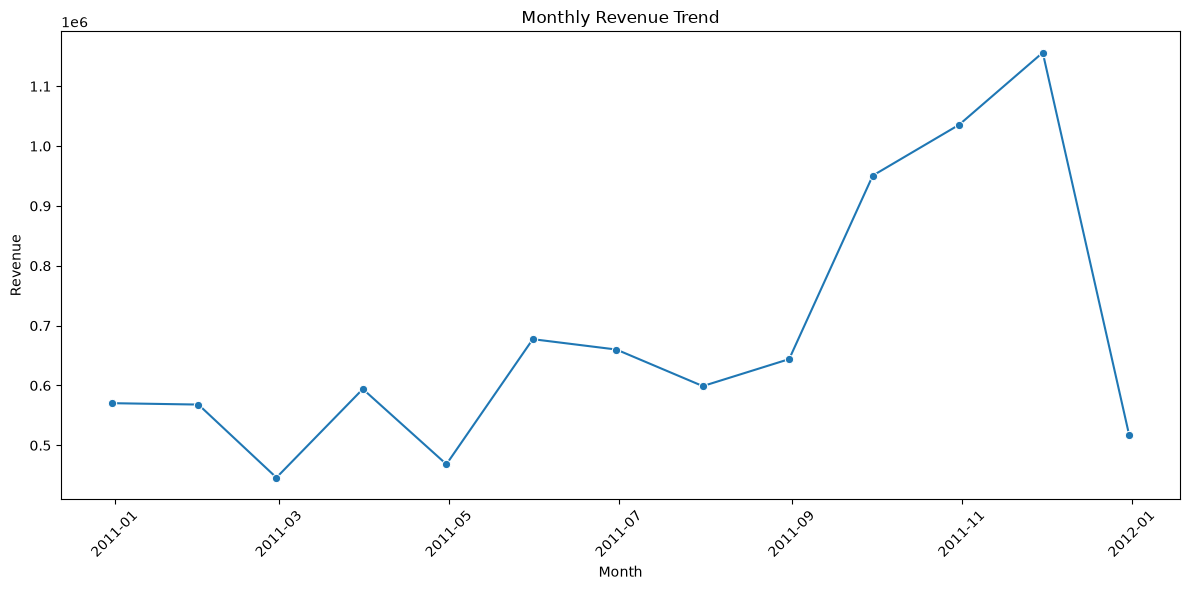

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_revenue,
    x='InvoiceDate',
    y='TotalAmount',
    marker='o'
)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/monthly_revenue.png')
plt.show()

In [33]:
country_revenue = (
    df.groupby('Country')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

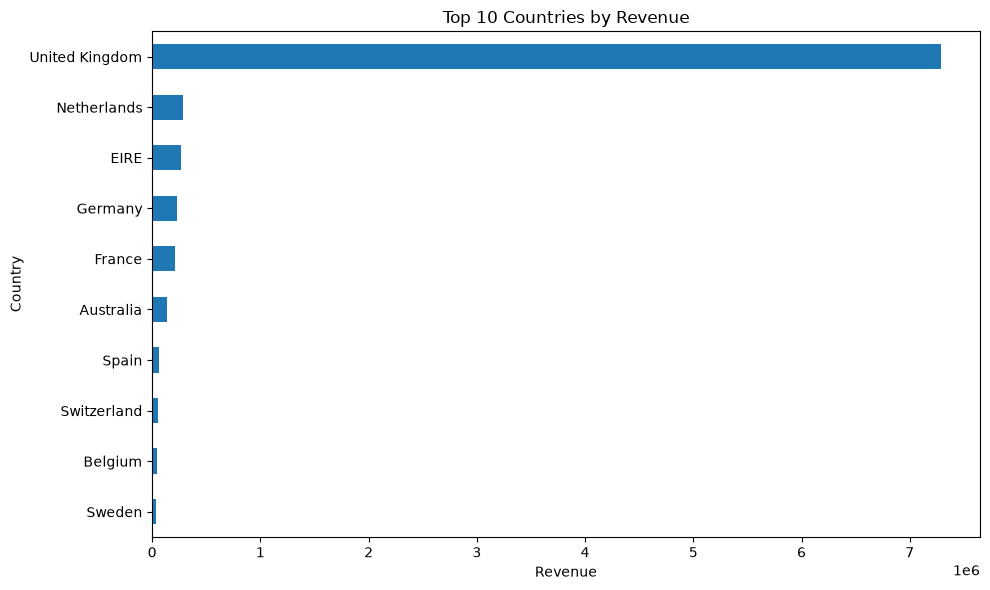

In [ ]:
plt.figure(figsize=(10, 6))
country_revenue.sort_values().plot(kind='barh')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../visuals/sales_by_country.png')
plt.show()

In [35]:
top_products = (
    df.groupby('Description')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

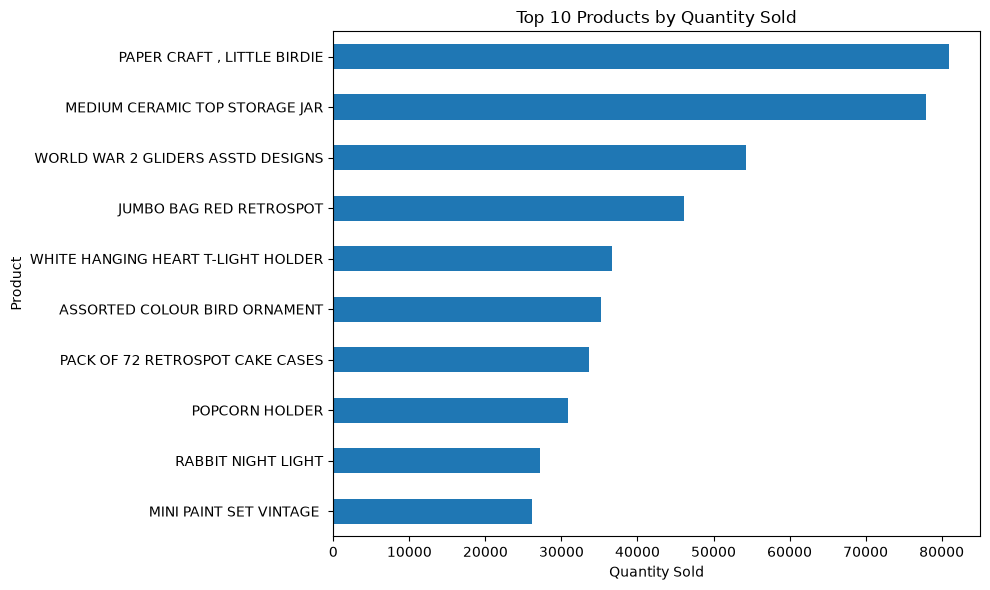

In [36]:
plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('../visuals/top_products.png')
plt.show()

In [38]:
top_customers = (
    df.groupby('CustomerID')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_customers

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: TotalAmount, dtype: float64

In [39]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [40]:
customer_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

In [41]:
quantity = (
    df.groupby('CustomerID')['Quantity']
      .sum()
      .reset_index(name='TotalQuantity')
)
customer_df = customer_df.merge(
    quantity,
    on='CustomerID',
    how='left'
)

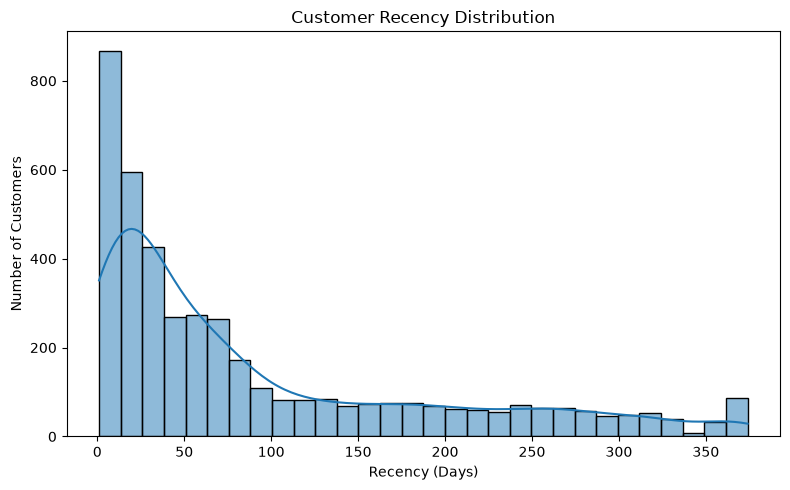

In [42]:
plt.figure(figsize=(8, 5))
sns.histplot(
    customer_df['Recency'],
    bins=30,
    kde=True
)
plt.title('Customer Recency Distribution')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../visuals/recency_distribution.png')
plt.show()

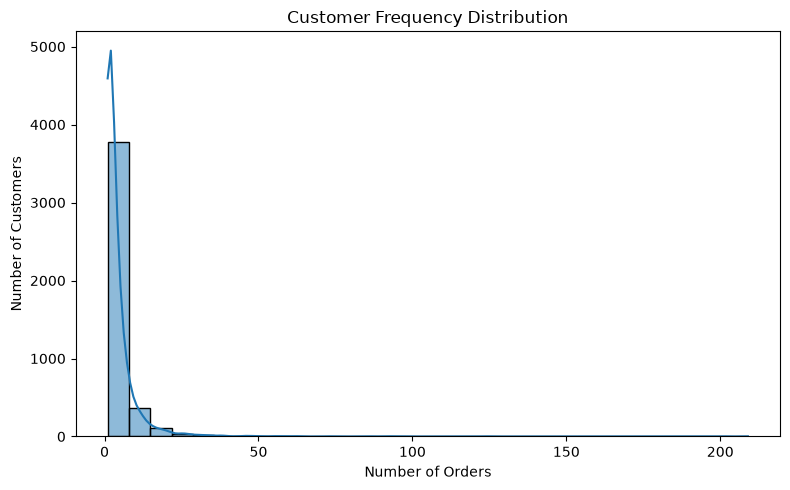

In [43]:
plt.figure(figsize=(8, 5))
sns.histplot(
    customer_df['Frequency'],
    bins=30,
    kde=True
)
plt.title('Customer Frequency Distribution')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../visuals/frequency_distribution.png')
plt.show()

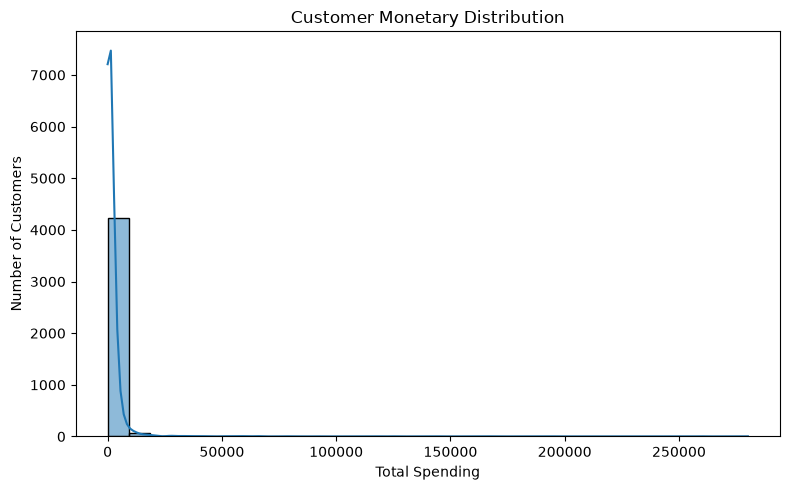

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(
    customer_df['Monetary'],
    bins=30,
    kde=True
)
plt.title('Customer Monetary Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../visuals/monetary_distribution.png')
plt.show()

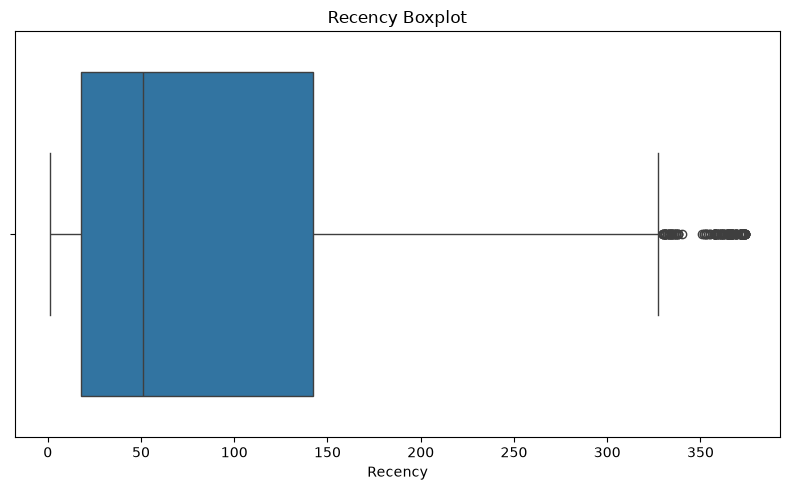

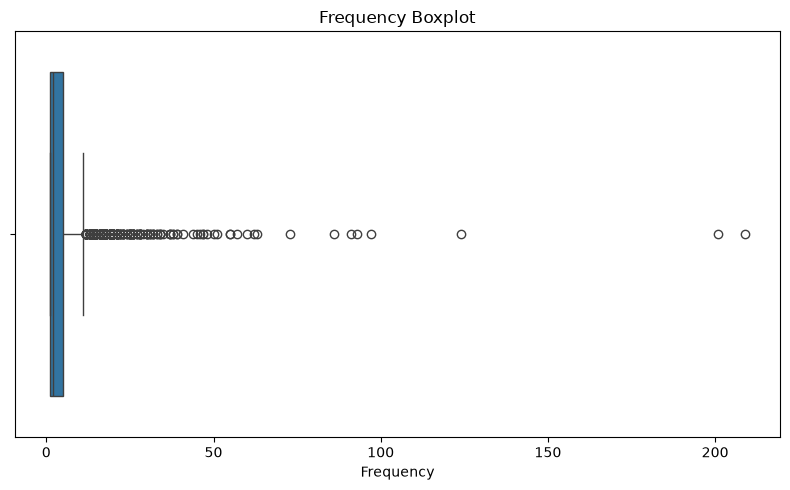

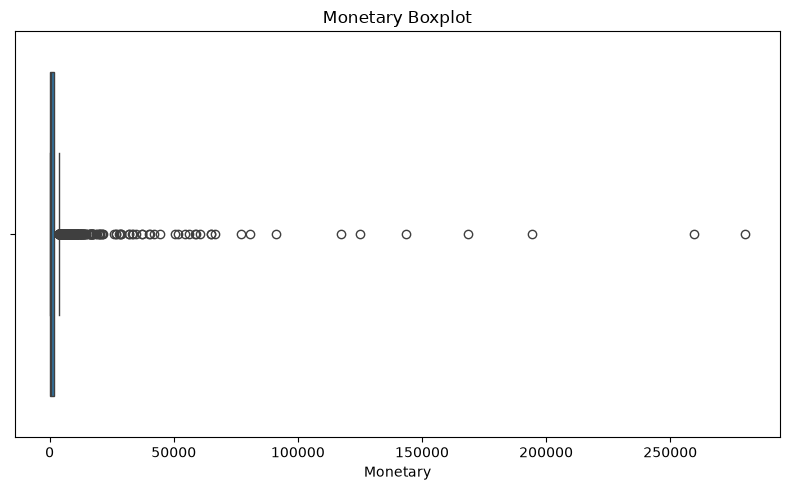

In [45]:
figures = ['Recency', 'Frequency', 'Monetary']
for column in figures:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=customer_df[column])
    plt.title(f'{column} Boxplot')
    plt.tight_layout()
    plt.savefig(f'../visuals/{column.lower()}_boxplot.png')
    plt.show()

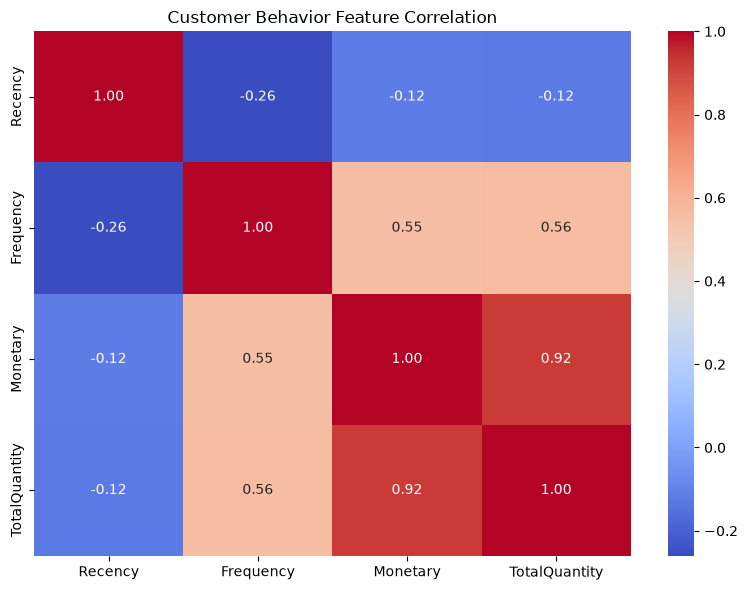

In [ ]:
rfm_columns = [
    'Recency',
    'Frequency',
    'Monetary',
    'TotalQuantity'
]
correlation = customer_df[rfm_columns].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title('Customer Behavior Feature Correlation')
plt.tight_layout()
plt.savefig('../visuals/correlation_heatmap.png')
plt.show()

In [ ]:
def remove_iqr_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[
        (data[column] >= lower_bound) &
        (data[column] <= upper_bound)
    ]

In [ ]:
customer_model_df = customer_df.copy()
for column in ['Monetary', 'Frequency', 'Recency']:
    customer_model_df = remove_iqr_outliers(
        customer_model_df,
        column
    )

In [49]:
print("Original customers:", len(customer_df))
print("Customers after outlier treatment:", len(customer_model_df))

Original customers: 4338
Customers after outlier treatment: 3750


In [50]:
features = [
    'Recency',
    'Frequency',
    'Monetary'
]

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    customer_model_df[features]
)

In [53]:
from sklearn.cluster import KMeans

In [54]:
inertia = []
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

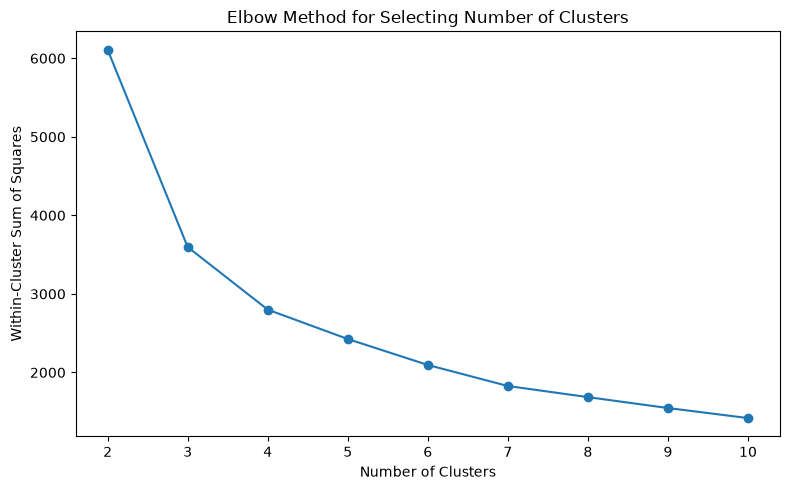

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares')
plt.title('Elbow Method for Selecting Number of Clusters')
plt.tight_layout()
plt.savefig('../visuals/elbow_curve.png')
plt.show()

In [56]:
from sklearn.metrics import silhouette_score

In [57]:
silhouette_scores = {}
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(
        scaled_features,
        labels
    )
    silhouette_scores[k] = score
    print(
        f"Clusters: {k}, "
        f"Silhouette Score: {score:.4f}"
    )

Clusters: 2, Silhouette Score: 0.4400
Clusters: 3, Silhouette Score: 0.4506
Clusters: 4, Silhouette Score: 0.4096
Clusters: 5, Silhouette Score: 0.3892
Clusters: 6, Silhouette Score: 0.3593
Clusters: 7, Silhouette Score: 0.3627
Clusters: 8, Silhouette Score: 0.3599
Clusters: 9, Silhouette Score: 0.3355
Clusters: 10, Silhouette Score: 0.3456


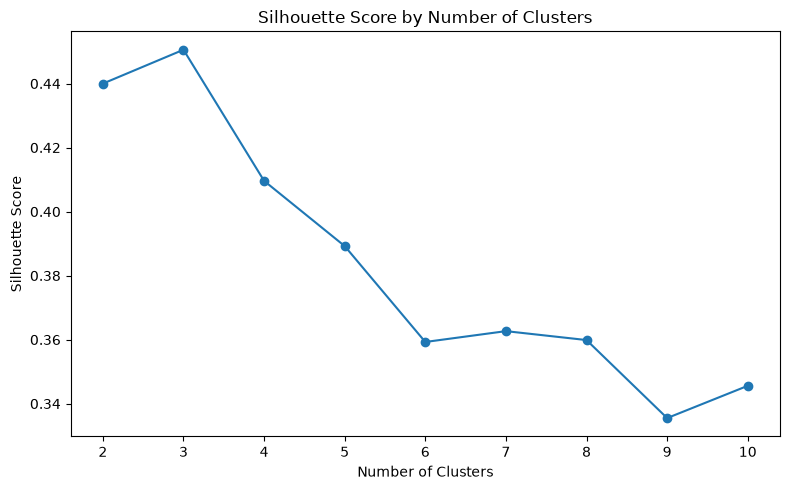

In [58]:
plt.figure(figsize=(8, 5))
plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker='o'
)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.tight_layout()
plt.savefig('../visuals/silhouette_scores.png')
plt.show()

In [59]:
optimal_k = 3
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)
customer_model_df['Cluster'] = kmeans.fit_predict(
    scaled_features
)

In [60]:
cluster_summary = (
    customer_model_df
    .groupby('Cluster')
    [['Recency', 'Frequency', 'Monetary', 'TotalQuantity']]
    .mean()
)
cluster_summary

,Recency,Frequency,Monetary,TotalQuantity
Cluster,,,,
0,256.438669,1.366944,378.009792,205.856549
1,40.713609,5.217751,1913.282640,1176.021302
2,54.496140,1.981472,550.918730,348.665466


In [61]:
cluster_names = {
    0: 'Premium Customers',
    1: 'Regular Customers',
    2: 'At-Risk Customers'
}
customer_model_df['Segment'] = (
    customer_model_df['Cluster']
    .map(cluster_names)
)

In [62]:
customer_segments = customer_model_df.copy()

In [63]:
customer_segments.to_csv(
    '../data/processed/customer_segments.csv',
    index=False
)

In [64]:
customer_df.to_csv(
    '../data/processed/customer_rfm.csv',
    index=False
)

In [65]:
segment_counts = (
    customer_segments['Segment']
    .value_counts()
)

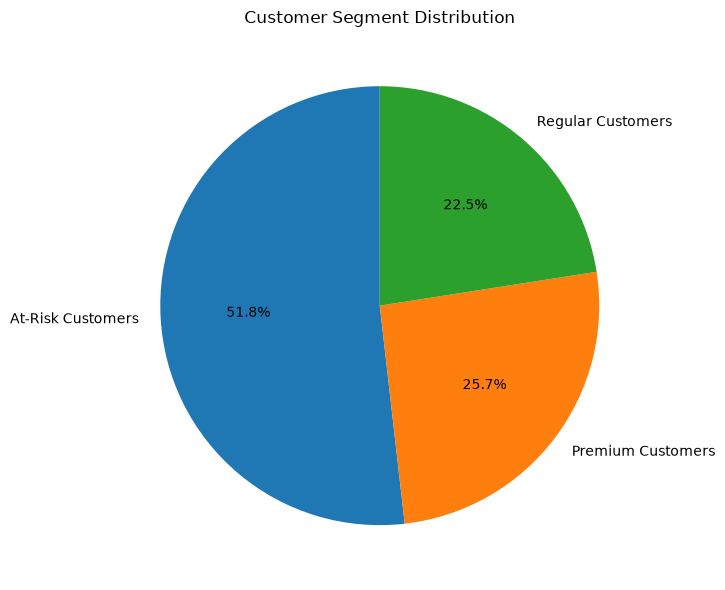

In [66]:
plt.figure(figsize=(8, 6))
plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Customer Segment Distribution')
plt.tight_layout()
plt.savefig(
    '../visuals/customer_segments_distribution.png'
)
plt.show()

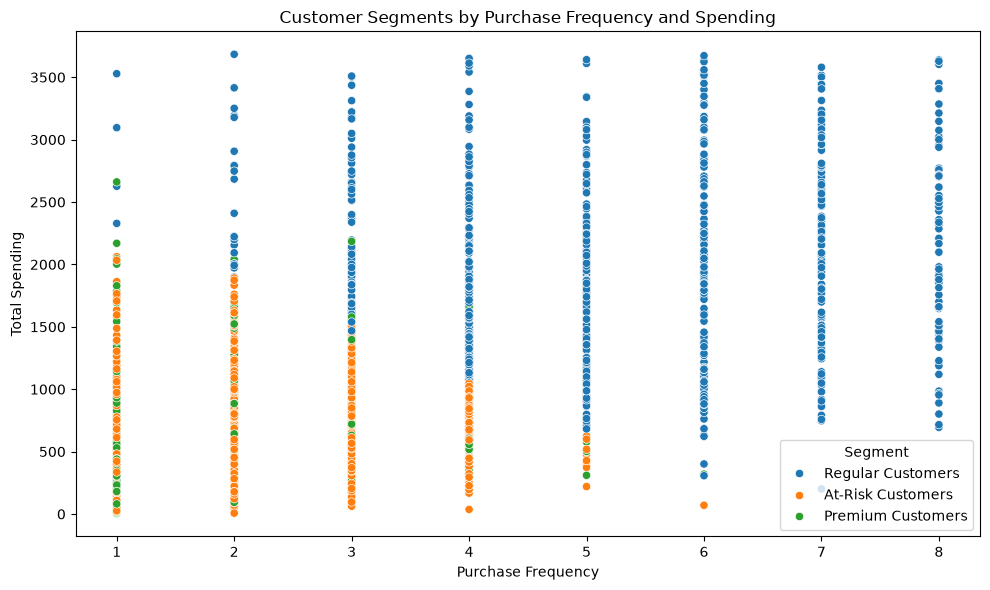

In [67]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customer_segments,
    x='Frequency',
    y='Monetary',
    hue='Segment'
)
plt.title(
    'Customer Segments by Purchase Frequency and Spending'
)
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spending')
plt.tight_layout()
plt.savefig(
    '../visuals/frequency_vs_monetary.png'
)
plt.show()

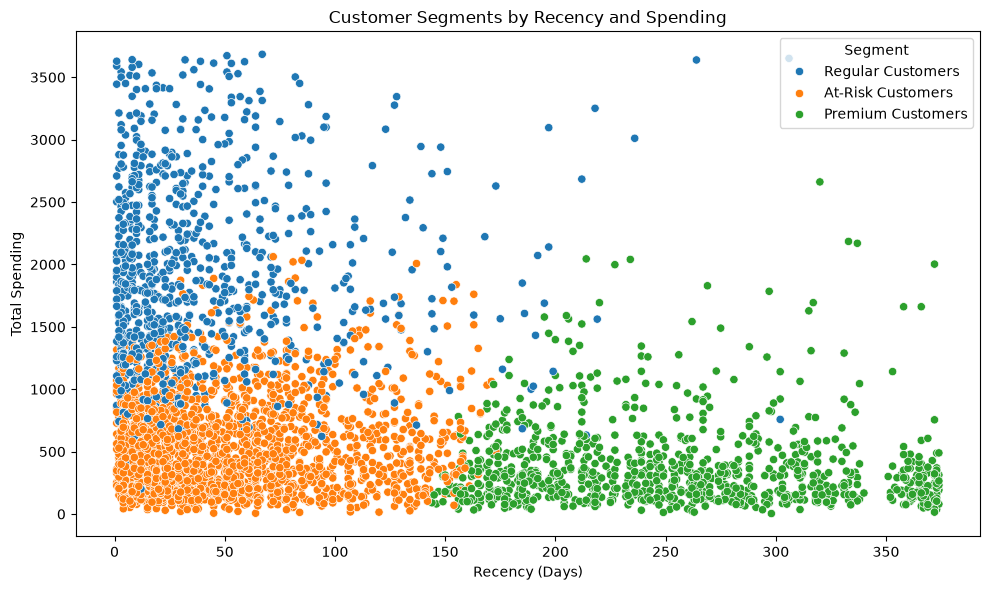

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customer_segments,
    x='Recency',
    y='Monetary',
    hue='Segment'
)
plt.title(
    'Customer Segments by Recency and Spending'
)
plt.xlabel('Recency (Days)')
plt.ylabel('Total Spending')
plt.tight_layout()
plt.savefig(
    '../visuals/recency_vs_monetary.png'
)
plt.show()

In [ ]:
segment_summary = (
    customer_segments
    .groupby('Segment')
    .agg(
        Customers=('CustomerID', 'count'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean'),
        Avg_Quantity=('TotalQuantity', 'mean')
    )
    .round(2)
)
segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Quantity
Segment,,,,,
At-Risk Customers,1943,54.50,1.98,550.92,348.67
Premium Customers,962,256.44,1.37,378.01,205.86
Regular Customers,845,40.71,5.22,1913.28,1176.02


In [70]:
segment_revenue = (
    customer_segments
    .groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

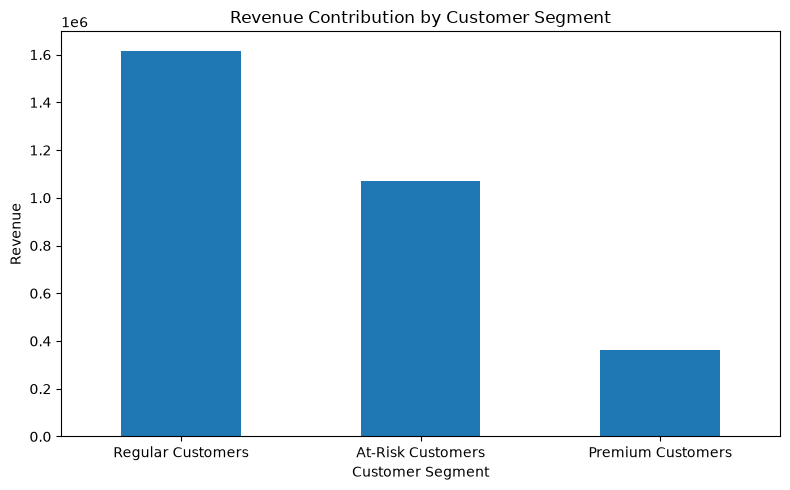

In [ ]:
plt.figure(figsize=(8, 5))
segment_revenue.plot(kind='bar')
plt.title('Revenue Contribution by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    '../visuals/revenue_by_segment.png'
)
plt.show()

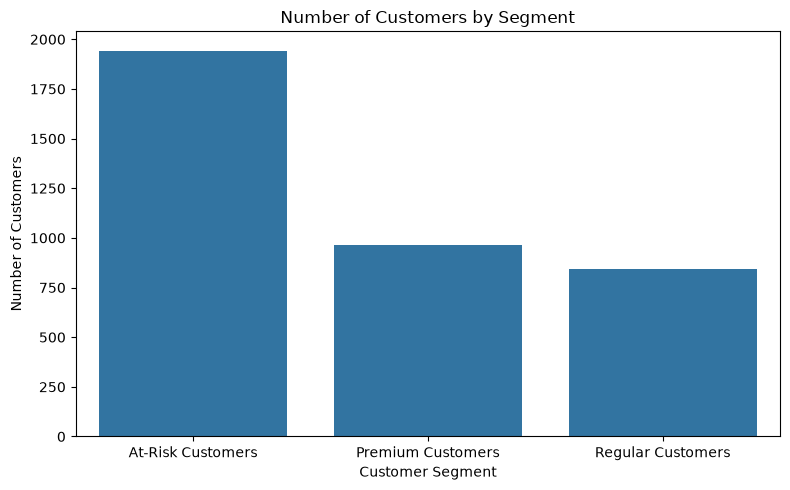

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=customer_segments,
    x='Segment',
    order=segment_counts.index
)
plt.title('Number of Customers by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig(
    '../visuals/customers_by_segment.png'
)
plt.show()

In [ ]:
import pandas as pd
path = r"C:\Users\Hp\Desktop\Customer-Segmentation-Retail-Analytics\data\processed\cleaned_sales_data.csv"
test_df = pd.read_csv(path)
print(test_df.shape)
print(test_df.columns)

(392692, 9)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='str')
